In [1]:
%load_ext autoreload
%autoreload 2

## Initial Preprocessing

In [4]:
import sys

sys.path.append("../")

In [5]:
from production import data_preprocessing as d

df = d.load_file()

## Schema and Data Validation 

In [11]:
from production import data_validations as v

v.validate_against_schema(df)

Since I'm working with a static file I will not be able to compare old vs new - but I will at least save off the old ratios so that I know what I want to compare against eventually

In [12]:
new_stats = v.calculate_psi_statistics(df)
old_stats = v.load_initial_statistics()

In [13]:
for colname in new_stats.keys():
    _, psi = v.population_stability_index(
        old_stats[colname], new_stats[colname], colname, pregrouped=True
    )
    if psi > 0.1:
        raise ValueError(
            f"Population for {colname} has shifted, check before running model"
        )

## Feature Engineering

In [14]:
from production import feature_engineering as f

In [15]:
# Save some data that I'm likely to need later for streamlit
diag = f.count_all_diag(df)
icd9 = f.load_icd9()
diag = f.join_diag_to_icd9(diag, icd9)
f.stash_data(df, diag)

True

In [16]:
df = f.create_dummies(df)
df = f.parse_weight_to_number(df)

In [17]:
df = f.add_prior_admissions(df)

In [18]:
alive, expired = f.filter_for_still_alive(df)
# Validate that nobody who expired was readmitted later
assert expired[expired["readmitted_dummy"] == 1].count()["encounter_id"] == 0

In [19]:
alive = f.compress_medicine_columns(alive)

In [ ]:
icd9_features = f.icd9_featurization(icd9)
alive = f.add_icd9_features(alive, icd9_features)
alive = f.add_random_feature(alive)

In [ ]:
final_feature_df = f.select_final_features(alive)

## Model Training

In [ ]:
from production import model as m

In [ ]:
X, y = m.split_X_and_y(final_feature_df)
X_train, X_test, y_train, y_test = m.train_test_split(X, y)

In [ ]:
model = m.train_model(X_train, y_train)
output_metrics = m.calculate_metrics(model, X_test, y_test)

In [ ]:
champion_model = m.compare_current_to_champion(model, output_metrics, "precision")

## Model Calibration

Initial calibration error (perfectly calibrated = 0): 0.226
Initial Brier score (lower = better): 0.28550323843955994


C:\Users\richw\PycharmProjects\readmission\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


=====================Post Calibration analysis=====================
Final calibration error (perfectly calibrated = 0): 0.026
Final Brier score (lower = better): 0.231


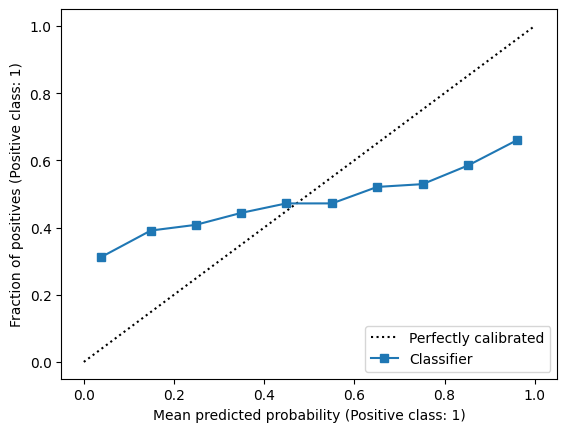

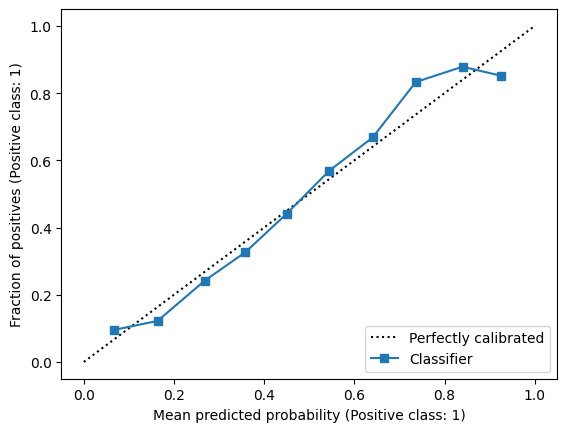

In [45]:
from production import model_calibration as mc

calibrated_model, calibrated_metrics = mc.run_calibration_process(
    champion_model, X_train, y_train, X_test, y_test
)

In [46]:
mc.save_calibrated_model(calibrated_model)

True